# Helmet detection: reproducible training and evaluation

This notebook re-runs the **original model and training setup unchanged** and evaluates it properly:

- the model is `create_model()` from `models/model.py` and the data pipeline is `get_data_generators()` from `scripts/train.py`, both untouched;
- training uses the original settings (10 epochs, `EarlyStopping(monitor='val_loss', patience=3)`, batch size 32);
- the dataset is rebuilt from the public annotations by `scripts/prepare_data.py` with a fixed seed, so the numbers can be reproduced;
- evaluation adds a majority-class baseline, a confusion matrix, per-class precision / recall and a look at the mistakes.

The original run (recorded in `notebooks/train_model.ipynb` and `notebooks/evaluate_model.ipynb`) reached 62.5% test accuracy, but its exact train/test split was not saved and therefore cannot be re-created. This notebook is the reproducible version.

In [1]:
import os, sys, json, warnings
warnings.filterwarnings("ignore")
os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "2")
os.chdir(os.path.abspath(".."))          # run from the project root, as the original scripts expect
sys.path.extend(["models", "scripts"])

import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score

from model import create_model              # original architecture
from train import get_data_generators       # original data pipeline

sns.set_theme(style="whitegrid")
tf.keras.utils.set_random_seed(42)
print("TensorFlow", tf.__version__)

TensorFlow 2.18.0


## 1. Data

The images show motorcycle and bicycle riders; each image is labelled `helmet` or `no_helmet` (see `scripts/prepare_data.py` for the labelling rule).

In [2]:
split = json.load(open("results/data_split.json"))
counts = pd.DataFrame(split["counts"]).T.fillna(0).astype(int)
counts["total"] = counts.sum(axis=1)
print(split["rule"])
counts

no_helmet if any 'Without Helmet' box, else helmet


,helmet,no_helmet,total
test,102,50,152
train,395,214,609


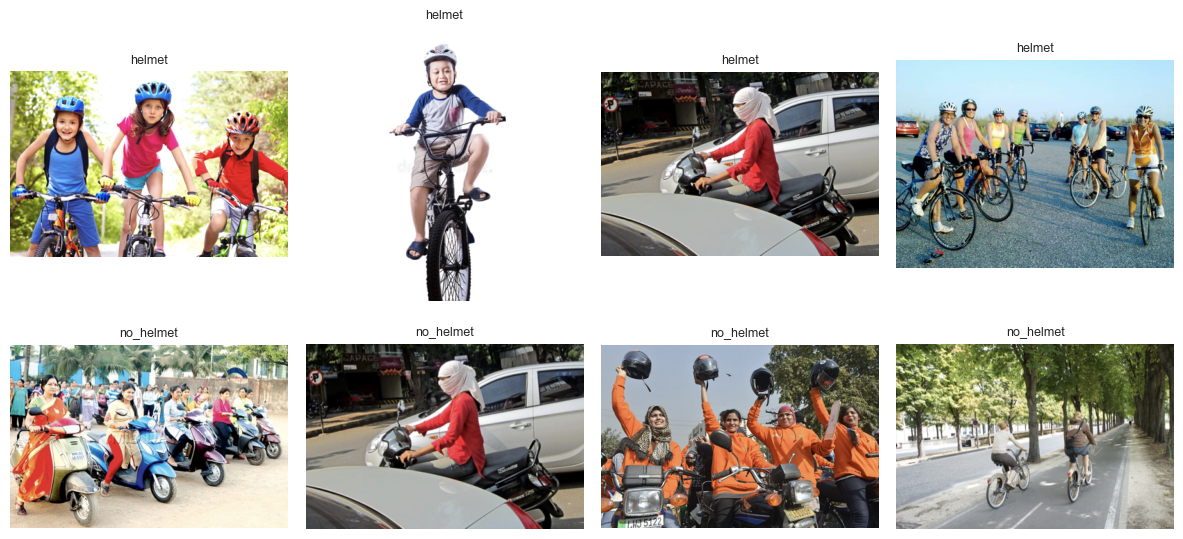

In [3]:
# a few examples of each class
from PIL import Image
import random
fig, axes = plt.subplots(2, 4, figsize=(12, 6))
for row, cls in enumerate(["helmet", "no_helmet"]):
    folder = f"data/helmet_detection/train/{cls}"
    for ax, f in zip(axes[row], random.Random(0).sample(sorted(os.listdir(folder)), 4)):
        ax.imshow(Image.open(os.path.join(folder, f)).convert("RGB")); ax.axis("off"); ax.set_title(cls, fontsize=9)
plt.tight_layout(); plt.show()

## 2. Training (original setup)

In [4]:
train_generator, validation_generator = get_data_generators()
print("classes:", train_generator.class_indices)

model = create_model()
early_stopping = EarlyStopping(monitor="val_loss", patience=3)

history = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // 32,
    epochs=10,
    validation_data=validation_generator,
    validation_steps=validation_generator.samples // 32,
    callbacks=[early_stopping],
    verbose=2,
)

Found 488 images belonging to 2 classes.


Found 121 images belonging to 2 classes.


classes: {'helmet': 0, 'no_helmet': 1}


Epoch 1/10


15/15 - 29s - 2s/step - accuracy: 0.6294 - loss: 0.7121 - val_accuracy: 0.6667 - val_loss: 0.6479


...

15/15 - 22s - 1s/step - accuracy: 0.6513 - loss: 0.6577 - val_accuracy: 0.6146 - val_loss: 0.7371


Epoch 4/10


15/15 - 4s - 278ms/step - accuracy: 0.5938 - loss: 0.7544 - val_accuracy: 0.6667 - val_loss: 0.6506


Epoch 5/10


15/15 - 22s - 1s/step - accuracy: 0.6645 - loss: 0.6106 - val_accuracy: 0.6354 - val_loss: 0.6510


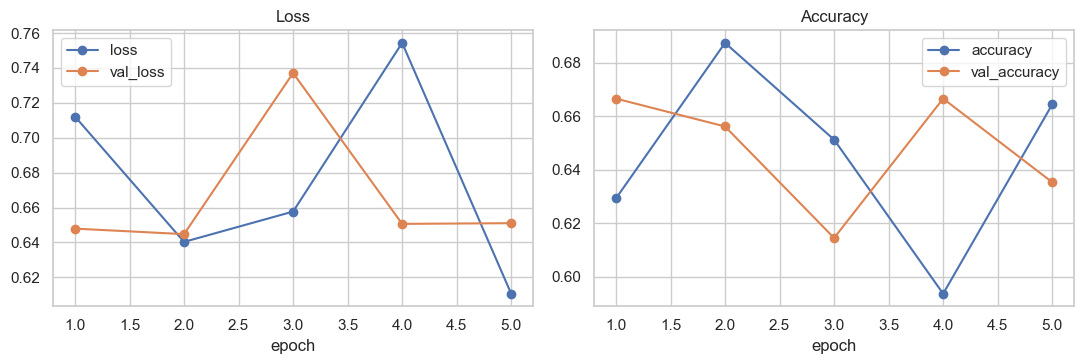

,accuracy,loss,val_accuracy,val_loss
1,0.629,0.712,0.667,0.648
2,0.688,0.640,0.656,0.645
3,0.651,0.658,0.615,0.737
4,0.594,0.754,0.667,0.651
5,0.664,0.611,0.635,0.651


In [5]:
h = pd.DataFrame(history.history); h.index += 1
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
h[["loss", "val_loss"]].plot(ax=axes[0], marker="o", title="Loss")
h[["accuracy", "val_accuracy"]].plot(ax=axes[1], marker="o", title="Accuracy")
for ax in axes: ax.set_xlabel("epoch")
plt.tight_layout(); plt.savefig("results/training_curves.png", dpi=130); plt.show()
h.round(3)

## 3. Evaluation on the held-out test set

In [6]:
test_gen = ImageDataGenerator(rescale=1./255).flow_from_directory(
    "data/helmet_detection/test", target_size=(224, 224), batch_size=32, class_mode="binary", shuffle=False)

probs = model.predict(test_gen, verbose=0).ravel()
y_true = test_gen.classes
y_pred = (probs > 0.5).astype(int)
names = list(test_gen.class_indices)          # index 0 / 1

acc = (y_true == y_pred).mean()
majority = max(np.bincount(y_true)) / len(y_true)
print(f"test accuracy            : {acc:.3f}   ({(y_true == y_pred).sum()} / {len(y_true)})")
print(f"majority-class baseline  : {majority:.3f}   (always predict '{names[int(np.argmax(np.bincount(y_true)))]}')")
print(f"ROC-AUC                  : {roc_auc_score(y_true, probs):.3f}")
print()
print(classification_report(y_true, y_pred, target_names=names, digits=3))

Found 152 images belonging to 2 classes.


test accuracy            : 0.691   (105 / 152)
majority-class baseline  : 0.671   (always predict 'helmet')
ROC-AUC                  : 0.661

              precision    recall  f1-score   support

      helmet      0.698     0.951     0.805       102
   no_helmet      0.615     0.160     0.254        50

    accuracy                          0.691       152
   macro avg      0.657     0.555     0.529       152
weighted avg      0.671     0.691     0.624       152



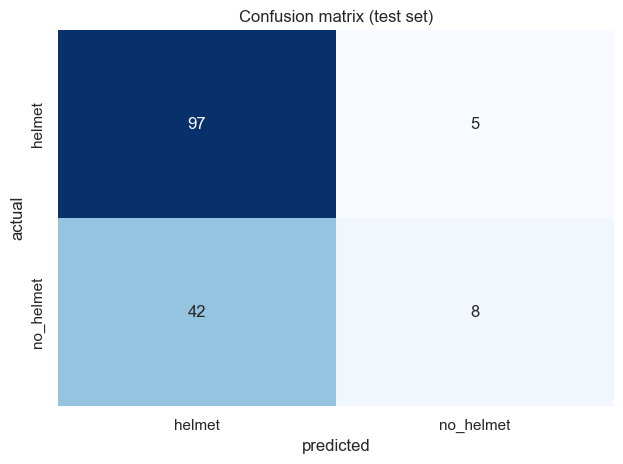

In [7]:
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=names, yticklabels=names, cbar=False)
plt.xlabel("predicted"); plt.ylabel("actual"); plt.title("Confusion matrix (test set)")
plt.tight_layout(); plt.savefig("results/confusion_matrix.png", dpi=130); plt.show()

## 4. Mistakes

A look at the images the model gets wrong, with its predicted probability of the second class.

47 wrong of 152


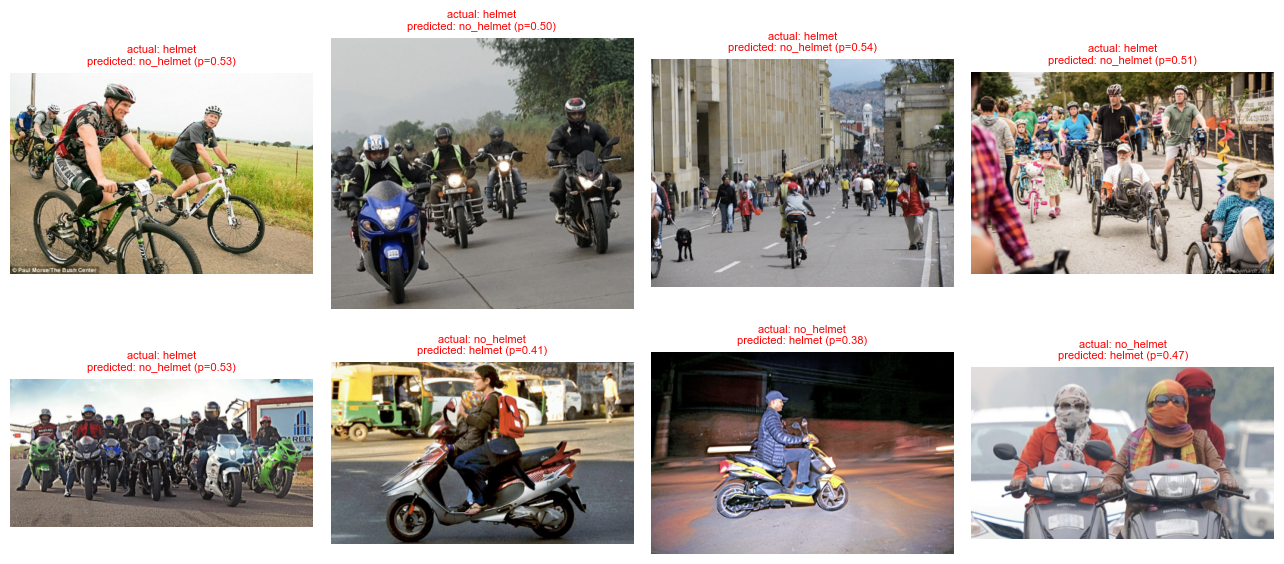

In [8]:
wrong = np.where(y_true != y_pred)[0]
print(f"{len(wrong)} wrong of {len(y_true)}")
fig, axes = plt.subplots(2, 4, figsize=(13, 6.2))
for ax in axes.flat: ax.axis("off")
for ax, i in zip(axes.flat, wrong[:8]):
    ax.imshow(Image.open(test_gen.filepaths[i]).convert("RGB"))
    ax.set_title(f"actual: {names[y_true[i]]}\npredicted: {names[y_pred[i]]} (p={probs[i]:.2f})", fontsize=8, color="red")
plt.tight_layout(); plt.savefig("results/mistakes.png", dpi=130); plt.show()

In [9]:
results = {
    "train_images": int(train_generator.samples), "validation_images": int(validation_generator.samples),
    "test_images": int(len(y_true)), "epochs_trained": int(len(h)),
    "test_accuracy": round(float(acc), 4), "majority_baseline": round(float(majority), 4),
    "roc_auc": round(float(roc_auc_score(y_true, probs)), 4),
    "confusion_matrix": {"labels": names, "matrix": cm.tolist()},
}
json.dump(results, open("results/metrics.json", "w"), indent=2)
model.save("models/helmet_detection_model.h5", include_optimizer=False)   # weights only: ~45 MB instead of 134 MB
print(json.dumps(results, indent=2)); print("model size: %.1f MB" % (os.path.getsize("models/helmet_detection_model.h5") / 1e6))

{
  "train_images": 488,
  "validation_images": 121,
  "test_images": 152,
  "epochs_trained": 5,
  "test_accuracy": 0.6908,
  "majority_baseline": 0.6711,
  "roc_auc": 0.6606,
  "confusion_matrix": {
    "labels": [
      "helmet",
      "no_helmet"
    ],
    "matrix": [
      [
        97,
        5
      ],
      [
        42,
        8
      ]
    ]
  }
}
model size: 44.7 MB


## Conclusions

- On the held-out test set the original model reaches **69.1% accuracy (105 / 152)**. That is only **2 points above the 67.1% majority-class baseline** (always answering `helmet`), and the ROC-AUC is 0.66, so the model has learned very little.
- It is strongly biased towards `helmet`: it finds **95%** of the helmet images but only **16% of the `no_helmet` images** (8 of 50). Since missing a rider without a helmet is the expensive mistake, accuracy alone makes the model look better than it is.
- Training does not settle: loss and accuracy jump from epoch to epoch and early stopping ends the run after 5 epochs. Many predicted probabilities are close to 0.5, i.e. the model is often undecided.
- Some of the errors come from the task definition rather than the network. The dataset is annotated per rider, but this classifier gets **one label per image**, and many pictures contain several riders, small riders or crowds (see the mistakes above), so a single image label is ambiguous.

**What would help, without changing the idea of the project:** class weights or balanced sampling, data augmentation, more epochs with a lower learning rate, and a pretrained backbone. A detector (e.g. YOLO) trained on the per-rider boxes would match the data far better than image-level classification.